<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')
%matplotlib inline

# Load the dataset
df = pd.read_csv('Crop_training_data_FULL _1.csv')

# Display basic info
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2100, 14)


,crop,temperature,rainfall,sunshine_hours,ph,organic_carbon,cec,awc,bulk_density,rooting_depth_m,texture,texture_code,suitability,suitability_class
0,Brinjal,31.672319,552.301720,9.366146,7.846648,1.084386,7.500302,0.019584,1.015852,0.417367,loamy sand,2,0.890,Suitable
1,Brinjal,25.933033,846.800369,7.149805,5.875672,0.794558,8.856502,0.018194,1.490377,0.994582,clay,7,0.850,Suitable
2,Brinjal,39.811213,1062.720610,7.013234,6.458209,0.992560,7.520904,0.036535,1.429336,1.092278,sandy loam,3,0.813,Suitable
3,Brinjal,18.849110,1829.479764,6.036585,6.532794,2.341503,11.694835,0.016350,1.654897,0.758520,loam,4,0.762,Unsuitable
4,Brinjal,34.574596,2383.861727,3.637588,7.563233,1.114877,27.785558,0.020950,1.001526,0.304485,clay loam,6,0.627,Unsuitable


 2. Initial Inspection

In [ ]:
# Check column names and data types
df.info()

# Summary statistics for numeric columns
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   crop               2100 non-null   str    
 1   temperature        2100 non-null   float64
 2   rainfall           2100 non-null   float64
 3   sunshine_hours     2100 non-null   float64
 4   ph                 2100 non-null   float64
 5   organic_carbon     2100 non-null   float64
 6   cec                2100 non-null   float64
 7   awc                2100 non-null   float64
 8   bulk_density       2100 non-null   float64
 9   rooting_depth_m    2100 non-null   float64
 10  texture            2100 non-null   str    
 11  texture_code       2100 non-null   int64  
 12  suitability        2100 non-null   float64
 13  suitability_class  2100 non-null   str    
dtypes: float64(10), int64(1), str(3)
memory usage: 229.8 KB


crop                 0
temperature          0
rainfall             0
sunshine_hours       0
ph                   0
organic_carbon       0
cec                  0
awc                  0
bulk_density         0
rooting_depth_m      0
texture              0
texture_code         0
suitability          0
suitability_class    0
dtype: int64

 3. Target Variable Analysis

suitability_class
Unsuitable    1246
Suitable       854
Name: count, dtype: int64


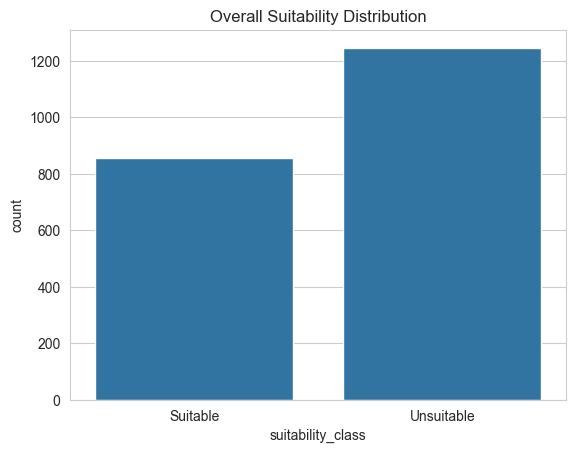

Number of crops: 21

Crops: <StringArray>
[       'Brinjal',          'Luffa',           'Okra',       'Cucumber',
    'Snake Gourd',   'Bitter Gourd',         'Radish',       'Capsicum',
 'Yard Long Bean',         'Banana',      'Pineapple',         'Ginger',
         'Papaya',  'Passion Fruit',   'Sweet Potato',       'Rambutan',
     'Mangosteen',         'Manioc',        'Kiriala',           'Yams',
       'Turmeric']
Length: 21, dtype: str


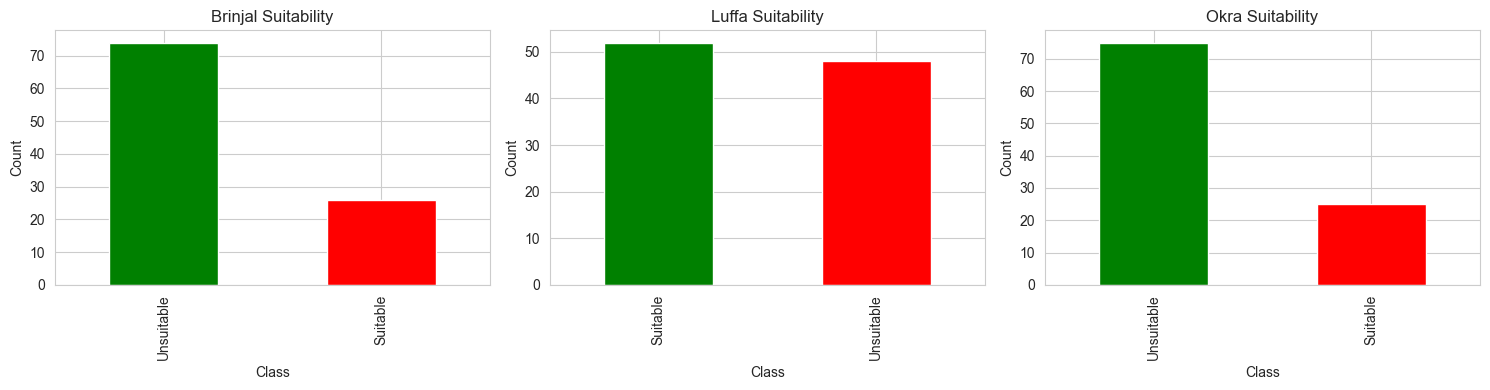

In [ ]:
# Distribution of suitability_class
print(df['suitability_class'].value_counts())
sns.countplot(x='suitability_class', data=df)
plt.title('Overall Suitability Distribution')
plt.show()

# Check per crop
crops = df['crop'].unique()
print("Number of crops:", len(crops))
print("\nCrops:", crops)

# For a few example crops, plot suitability distribution
example_crops = ['Brinjal', 'Luffa', 'Okra']  # pick any three
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, crop in zip(axes, example_crops):
    subset = df[df['crop'] == crop]
    subset['suitability_class'].value_counts().plot(kind='bar', ax=ax, color=['green', 'red'])
    ax.set_title(f'{crop} Suitability')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

4. Distributions of Numeric Features

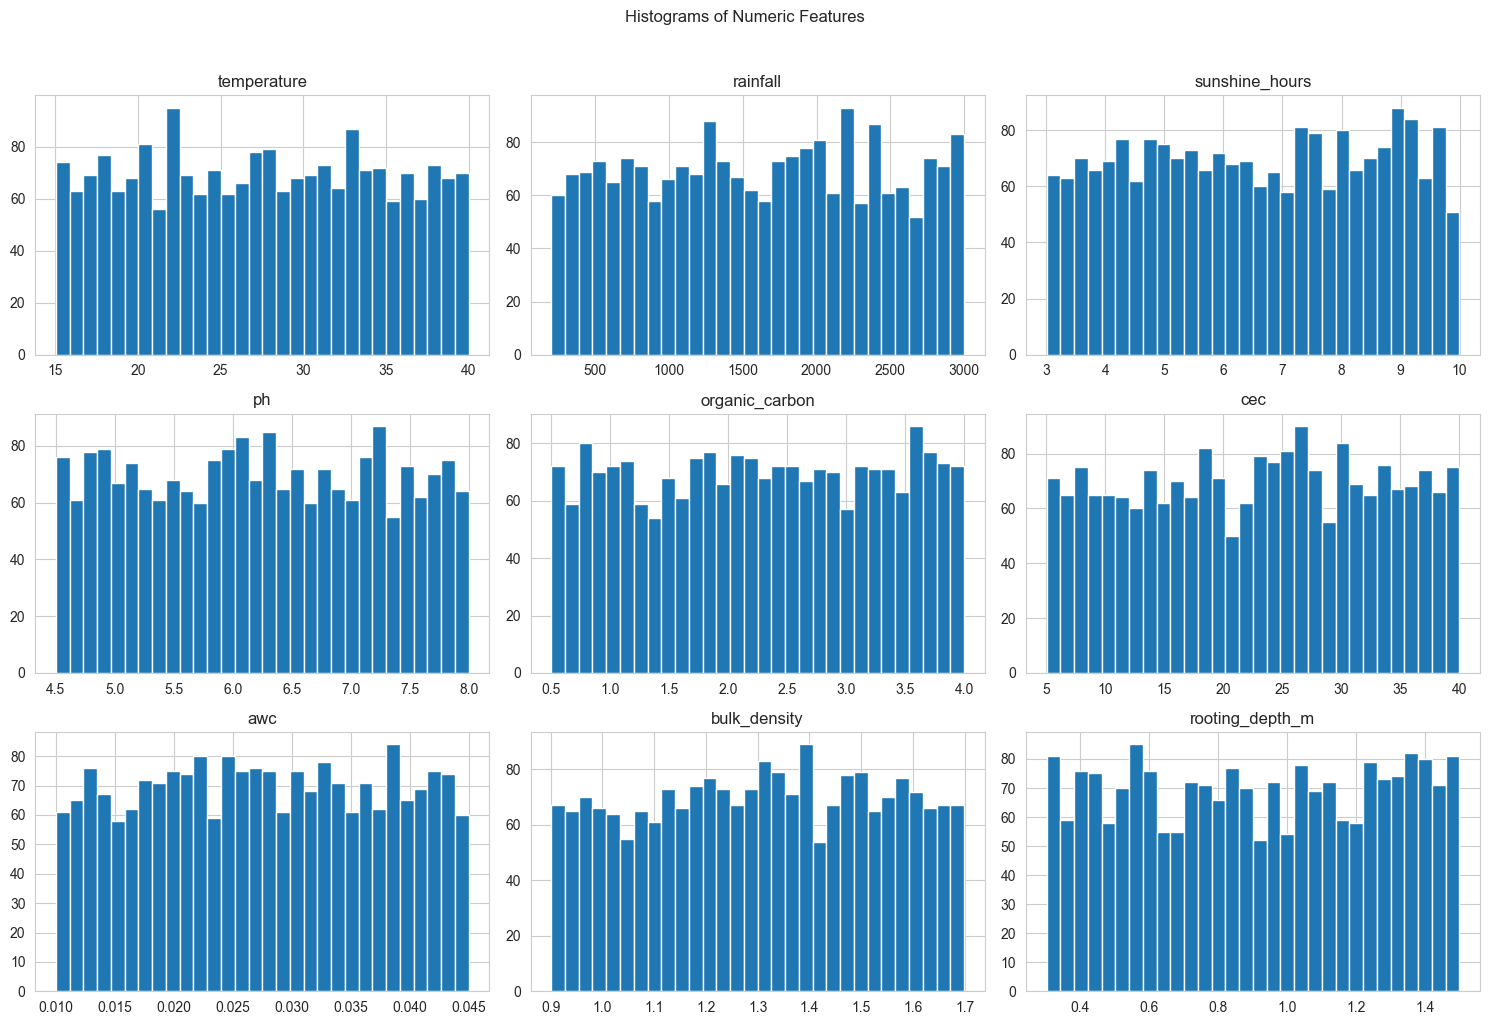

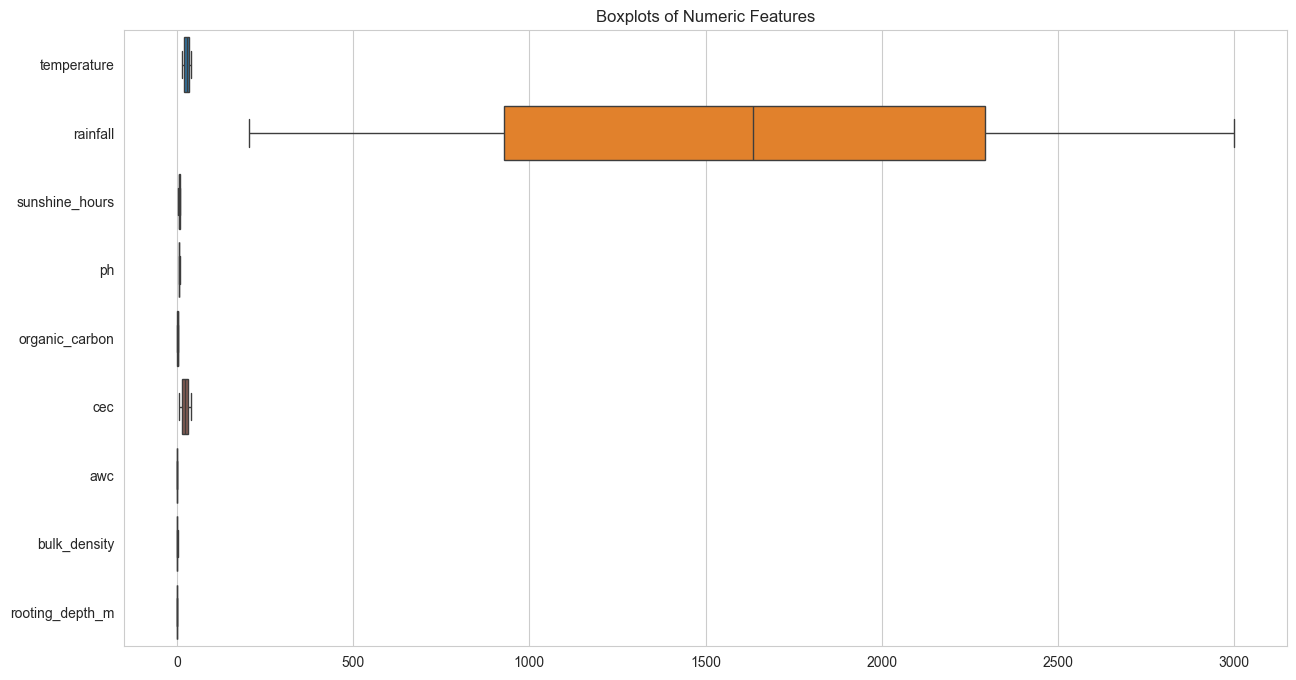

In [ ]:
# List of numeric features (excluding target, crop, texture name)
numeric_features = ['temperature', 'rainfall', 'sunshine_hours', 'ph',
                    'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m']

# Plot histograms
df[numeric_features].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numeric Features', y=1.02)
plt.tight_layout()
plt.show()

# Boxplots to spot outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[numeric_features], orient='h')
plt.title('Boxplots of Numeric Features')
plt.show()

5. Categorical Features

Unique textures: <StringArray>
['loamy sand', 'clay', 'sandy loam', 'loam', 'clay loam', 'silt loam', 'sand']
Length: 7, dtype: str

Texture value counts:
texture
clay loam     315
sandy loam    307
silt loam     307
loam          301
loamy sand    293
clay          292
sand          285
Name: count, dtype: int64

Texture to code mapping:
       texture  texture_code
22        sand             1
0   loamy sand             2
2   sandy loam             3
3         loam             4
6    silt loam             5
4    clay loam             6
1         clay             7


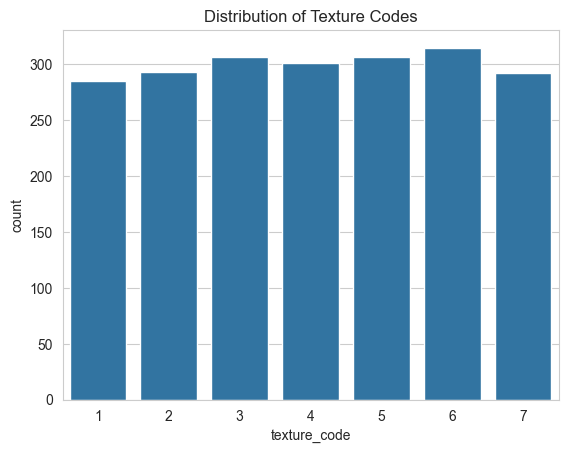

In [ ]:
# Texture and texture_code
print("Unique textures:", df['texture'].unique())
print("\nTexture value counts:")
print(df['texture'].value_counts())

# Relationship between texture and texture_code
texture_map = df[['texture', 'texture_code']].drop_duplicates().sort_values('texture_code')
print("\nTexture to code mapping:")
print(texture_map)

# Check if texture_code is ordinal (should be: sand=1, loamy sand=2, ... clay=7)
# Plot distribution of texture_code
sns.countplot(x='texture_code', data=df)
plt.title('Distribution of Texture Codes')
plt.show()

6. Relationships with Target Variable

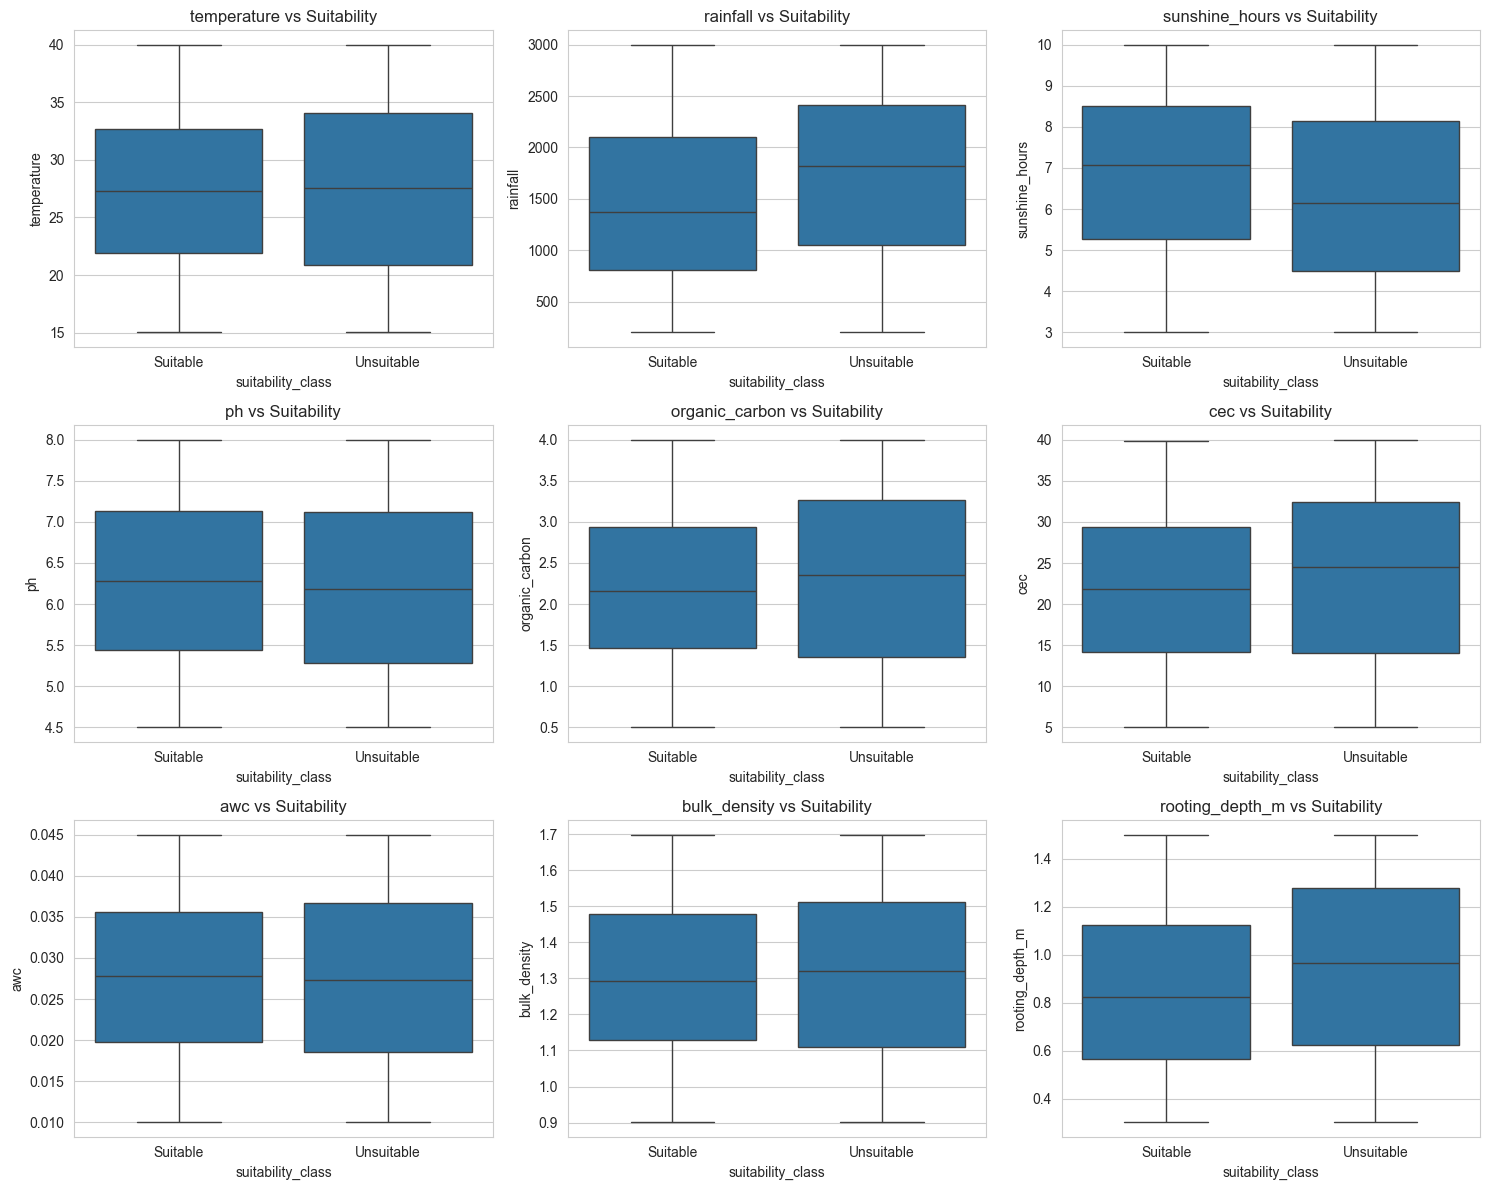

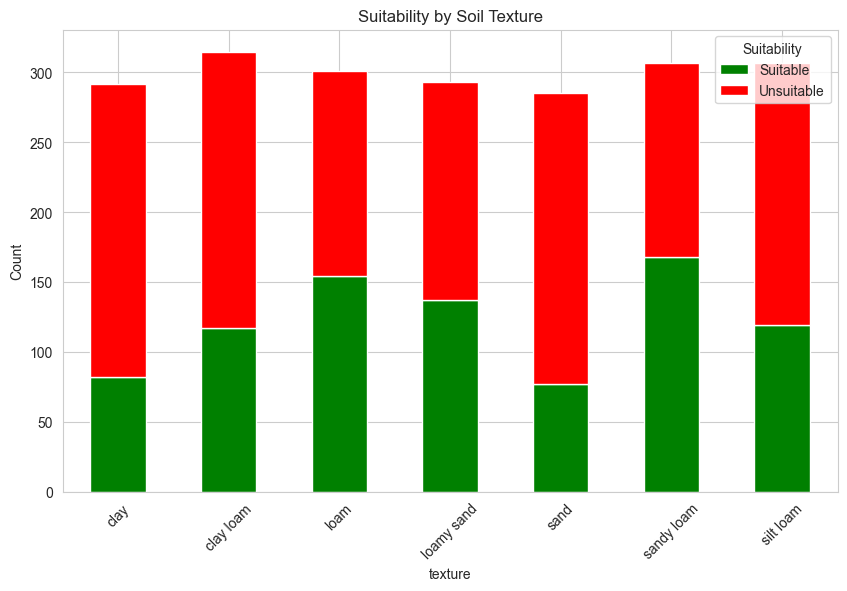

In [ ]:
# For each numeric feature, plot boxplots split by suitability
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, feature in enumerate(numeric_features):
    sns.boxplot(x='suitability_class', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} vs Suitability')
plt.tight_layout()
plt.show()

# For texture, create a stacked bar chart
suit_by_texture = pd.crosstab(df['texture'], df['suitability_class'])
suit_by_texture.plot(kind='bar', stacked=True, figsize=(10, 6), color=['green', 'red'])
plt.title('Suitability by Soil Texture')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Suitability')
plt.show()

 7. Correlation Analysis

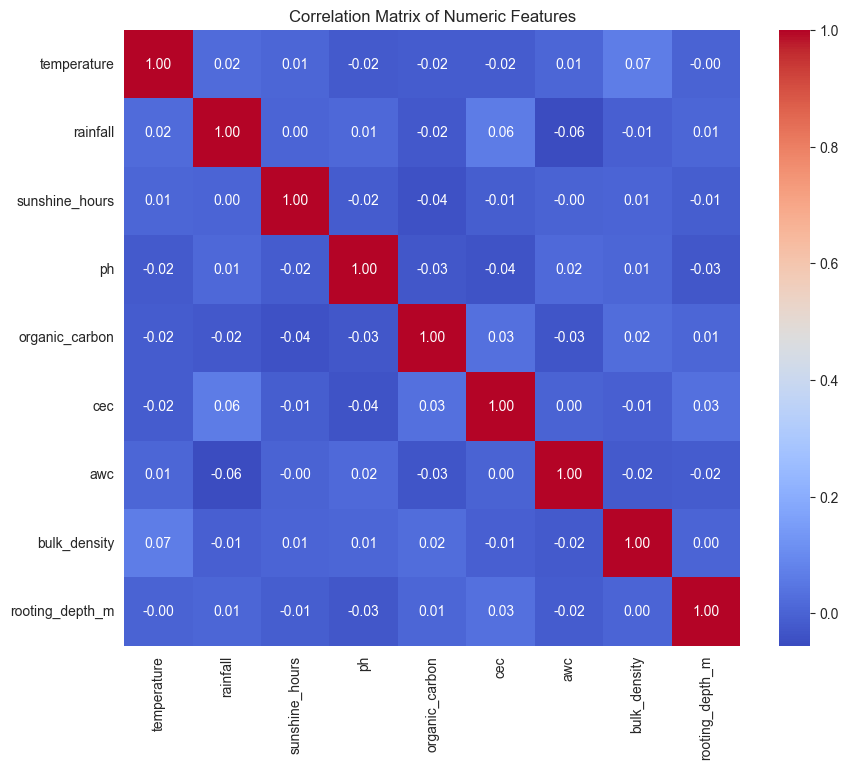

Correlation with target (point-biserial):
rainfall: -0.157
sunshine_hours: 0.128
rooting_depth_m: -0.120
cec: -0.078
organic_carbon: -0.049
bulk_density: -0.032
ph: 0.028
temperature: -0.013
awc: -0.001


In [ ]:
# Correlation matrix among numeric features
corr = df[numeric_features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# Check correlations with target (point-biserial correlation) – optional
from scipy.stats import pointbiserialr
target_binary = df['suitability_class'].map({'Suitable':1, 'Unsuitable':0})
corr_with_target = {}
for f in numeric_features:
    corr_with_target[f] = pointbiserialr(target_binary, df[f])[0]
print("Correlation with target (point-biserial):")
for k,v in sorted(corr_with_target.items(), key=lambda x: abs(x[1]), reverse=True):
    print(f"{k}: {v:.3f}")